In [1]:
# import deconstruct as c

# class InputEvent(c.Struct):
#     W: c.uint32
#     L: c.uint32
#     N: c.uint32
#     value: c.int32

class Task:
    def __init__(self, W, L, N, items, K):
        self.W = W
        self.L = L
        self.N = N # N = len(items)
        self.items = items
        self.K = K # moves per one item


In [2]:
class TaskGenerator:
    def __init__(self):
        raise NotImplementedError

    def Gen(self, n):
        pass

In [3]:
import ctypes
import numpy as np
from numpy.ctypeslib import ndpointer

In [4]:
solution_type = {
    "tower": 0,
    "random": 1,
    "greedy-random": 2,
    "lowest-fit": 3,
    "min-coverage": 4
}

In [5]:
import subprocess
import ctypes
import _ctypes
import os
import numpy as np
from pathlib import Path

lib = 0

from typing import Tuple, Optional

class ErrorInfo(ctypes.Structure):
    _fields_ = [("message", ctypes.c_char_p),
                ("error_code", ctypes.c_int)]

class CppException(Exception):
    """Custom exception for C++ errors"""
    def __init__(self, message, error_code):
        super().__init__(f"C++ Error {error_code}: {message}")
        self.error_code = error_code

def compile_cpp_library():
    # Define paths
    cpp_file = "./3d-packing/main.cpp"
    output_lib = "./libmodule.so"
    
    # Check if source file exists
    if not os.path.exists(cpp_file):
        raise FileNotFoundError(f"C++ source file not found at {cpp_file}")

    # g++ -std=c++20 -shared -fPIC -o ./libmodule.so ./3d-packing/main.cpp 
    # Compile command
    compile_cmd = [
        "g++",
        "-std=c++20",
        "-shared",
        "-fPIC",
        "-o", output_lib,
        cpp_file
    ]
    
    # Execute compilation
    try:
        result = subprocess.run(
            compile_cmd,
            check=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )
        print("Compilation successful!")
        print(result.stdout)
    except subprocess.CalledProcessError as e:
        print("Compilation failed!")
        print("Error message:")
        print(e.stderr)
        raise

def reload_cdll(lib_path):
    """Reloads a ctypes.CDLL library."""
    
    # Ensure the library path is absolute
    lib_path = os.path.abspath(lib_path)

    print(reload_cdll.loaded_libs)
    # Check if the library is currently loaded
    if lib_path in reload_cdll.loaded_libs:
        libcd = reload_cdll.loaded_libs[lib_path]
        
        # Unload the library
        _ctypes.dlclose(libcd._handle)
        del reload_cdll.loaded_libs[lib_path]
        
        
    # Load the library
    libcd = ctypes.CDLL(lib_path)
    reload_cdll.loaded_libs[lib_path] = libcd
    return libcd

reload_cdll.loaded_libs = {}

def prepare_cpp_solutions():
    compile_cpp_library()
    
    lib = reload_cdll('./libmodule.so')

    lib.process_task.argtypes = [
        ctypes.c_int, # n
        ctypes.c_int, # w
        ctypes.c_int, # l
        ctypes.c_int, # k - max_move_count
        ndpointer(ctypes.c_int, flags="C_CONTIGUOUS"), # items [dx0, dy0, dz0, dx1, dy1, dz1, ... ]
        ctypes.c_int, # solution_type
        ctypes.POINTER(ctypes.POINTER(ctypes.c_int)),  # moves [item_id, x, y, z, item_id, x, y, z, ...]
        ctypes.POINTER(ctypes.c_int),                  # move count (single int)
        ndpointer(ctypes.c_int, flags="C_CONTIGUOUS"), # pos [x, y, z, x, y, z, x, y, z, x, y, z]
        ctypes.POINTER(ErrorInfo)
    ]
    lib.process_task.restype = None
    
    lib.free_moves.argtypes = [ctypes.POINTER(ctypes.c_int)]
    lib.free_moves.restype = None

    lib.free_error.argtypes = [ctypes.POINTER(ErrorInfo)]
    lib.free_error.restype = None

    return lib

def get_solution(lib, n, items, w, l, k, solution_type_name):
    pos_array = np.empty((n * 3), dtype=np.int32)
    
    # Prepare output variables
    moves_array = ctypes.POINTER(ctypes.c_int)()
    moves_size = ctypes.c_int()

    error = ErrorInfo()

    try:
        lib.process_task(
            n, w, l, k, items,
            solution_type[solution_type_name],
            ctypes.byref(moves_array), ctypes.byref(moves_size),
            pos_array,
            ctypes.byref(error)
        )

        if error.message:
            raise CppException(error.message.decode('utf-8'), error.error_code)
        # Call the function
        # lib.generate_array(ctypes.byref(out_array), ctypes.byref(out_size))
        
        # Convert to Python list
        moves_result = [moves_array[i] for i in range(moves_size.value)]
        
        # Free memory
        return (moves_result, pos_array)
    except Exception as e:
        print(e)
    finally:
        lib.free_error(ctypes.byref(error))
        lib.free_moves(moves_array)
    return (0, 0)


In [6]:
def calculate_mass_centers(pos, items):
    """
    Calculate mass centers for each rectangle and the overall center
    
    Parameters:
        pos : (N,3) array of [x0,y0,z0] positions
        items : (N,3) array of [dx,dy,dz] dimensions
        
    Returns:
        individual_centers : (N,3) array of individual centers
        overall_center : (3,) array of combined mass center
    """
    # Calculate volumes (proportional to mass)
    volumes = items[:, 0] * items[:, 1] * items[:, 2]
    
    # Calculate individual centers (position + half dimensions)
    individual_centers = pos + items/2
    
    # Calculate overall mass center (weighted average)
    overall_center = np.sum(individual_centers * volumes[:, np.newaxis], axis=0) / np.sum(volumes)
    
    return overall_center

def calculate_total_volume(items):
    """
    Calculate total volume of all rectangular prisms
    
    Parameters:
        pos : (N,3) array - [x0,y0,z0] positions (not needed for volume)
        items : (N,3) array - [dx,dy,dz] dimensions
        
    Returns:
        total_volume : float - sum of all item volumes
    """
    # Volume for each item = dx * dy * dz
    volumes = items[:, 0] * items[:, 1] * items[:, 2]
    return np.sum(volumes)


In [55]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_3d_rectangles(pos, items, colors=['b'], alpha=0.5, ax=None):
    """
    Plot 3D rectangles given positions and dimensions.
    
    Parameters:
        pos : np.array of shape (N, 3) - [x0, y0, z0] positions
        items : np.array of shape (N, 3) - [dx, dy, dz] dimensions
        color : color of the rectangles
        alpha : transparency (0-1)
        ax : existing 3D axis (creates new if None)
    """
    if ax is None:
        fig = plt.figure(figsize=(5, 5))
        ax = fig.add_subplot(111, projection='3d')
    
    # Convert to numpy arrays if they aren't already
    pos = np.asarray(pos)
    items = np.asarray(items)
    
    # Verify shapes
    if pos.shape[1] != 3 or items.shape[1] != 3:
        raise ValueError("Input arrays must have shape (N, 3)")
    if len(pos) != len(items):
        raise ValueError("pos and items must have same length")

    i = -1
    for (x0, y0, z0), (dx, dy, dz) in zip(pos, items):
        i += 1
        # Define the 8 vertices of the rectangular prism
        vertices = [
            [x0, y0, z0],
            [x0+dx, y0, z0],
            [x0+dx, y0+dy, z0],
            [x0, y0+dy, z0],
            [x0, y0, z0+dz],
            [x0+dx, y0, z0+dz],
            [x0+dx, y0+dy, z0+dz],
            [x0, y0+dy, z0+dz]
        ]
        
        # Define the 6 faces using the vertices
        faces = [
            [vertices[0], vertices[1], vertices[2], vertices[3]],  # bottom
            [vertices[4], vertices[5], vertices[6], vertices[7]],  # top
            [vertices[0], vertices[1], vertices[5], vertices[4]],  # front
            [vertices[2], vertices[3], vertices[7], vertices[6]],  # back
            [vertices[1], vertices[2], vertices[6], vertices[5]],  # right
            [vertices[0], vertices[3], vertices[7], vertices[4]]   # left
        ]
        
        # Plot each face
        ax.add_collection3d(Poly3DCollection(
            faces, 
            facecolors=colors[i % len(colors)], 
            linewidths=1, 
            edgecolors='k', 
            alpha=alpha
        ))
    
    # Auto-scale the axes
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    # ax.autoscale_view()
    
    return ax

def show_solution(items, pos, solution_type_name, colors=['b'], alpha=0.5, ax=None):
    ax = plot_3d_rectangles(pos, items, colors=colors, alpha=alpha, ax=ax)
    
    # for i in range(1, len(items)):
    #     color = colors[i % len(colors)]
    #     plot_3d_rectangles(pos[i:i + 1], items[i:i + 1], colors=colors, ax=ax)  # Second in green
    # plot_3d_rectangles(pos[2:], items[2:], color='b', ax=ax)  # Third in blue

    # ax.set_xlim([0, w])
    # ax.set_ylim([0, l])
    # Set equal aspect ratio
    ax.set_box_aspect([1, 1, 1])  # This is the key line!
    
    # Auto-scale while maintaining aspect
    all_points = np.vstack([pos, pos + items])
    min_vals = all_points.min(axis=0)
    max_vals = all_points.max(axis=0)

    min_x = min_vals.min()
    max_x = max_vals.max()

    range_x = max_x - min_x
    
    ax.set_xlim(min_x - range_x * 0.1, max_x + range_x * 0.1)
    ax.set_ylim(min_x - range_x * 0.1, max_x + range_x * 0.1)
    ax.set_zlim(min_x - range_x * 0.1, max_x + range_x * 0.1)

    # Set ticks at zero
    # ax.set_xticks([0])
    # ax.set_yticks([0])
    # ax.set_zticks([0])
    # ax.set_box_aspect([1,1,1])
    ax.view_init(elev=20, azim=35)

    mass_center = calculate_mass_centers(pos, items)
    volume = calculate_total_volume(items)
    
    ax.set_title(
        solution_type_name
    )

    ax.text2D(
        0.65, 0.93,
        s="height:     " +
        str(max_vals[2]) +
        "\nbarycenter: " +
        str(round(mass_center[2], 2)) +
        "\nutil:       " + str(round(volume / (w * l * all_points.max(axis=0)[2]), 2)),
        fontsize=10, color='red',
        transform=ax.transAxes, ha='left', va='top',
        fontfamily='monospace'
    )
    # plt.tight_layout()
    # plt.show()


In [8]:
def plot_2d_rectangles(pos, items, colors=['b'], alpha=0.5, ax=None):
    """
    Plot rectangles in 2D
    
    Parameters:
        pos : np.array of shape (N, 3) - [x0, y0, z0] positions
        items : np.array of shape (N, 3) - [dx, dy, dz] dimensions
        color : color of the rectangles
        alpha : transparency (0-1)
        ax : existing axis (creates new if None)
        two_d : if True, draws 2D projection (dy becomes 1)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    pos = np.asarray(pos)
    items = np.asarray(items)
    
    if pos.shape[1] != 3 or items.shape[1] != 3:
        raise ValueError("Input arrays must have shape (N, 3)")
    if len(pos) != len(items):
        raise ValueError("pos and items must have same length")
    
    # For 2D projection (X-Z plane)
    i = -1
    for (x0, _, z0), (dx, _, dz) in zip(pos, items):
        i += 1
        rect = plt.Rectangle((x0, z0), dx, dz, 
                           facecolor=colors[i % len(colors)], 
                           edgecolor='k',
                           alpha=alpha)
        ax.add_patch(rect)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Z')
    ax.set_title('2D Projection (X-Z plane)')
    ax.grid(True)
    ax.set_aspect('equal')
    
    # Auto-scale the axes
    all_points = np.vstack([pos, pos + items])
    min_vals = all_points.min(axis=0)
    max_vals = all_points.max(axis=0)
    ranges = max_vals - min_vals
    padding = 0.1 * ranges
    
    ax.set_xlim(min_vals[0]-padding[0], max_vals[0]+padding[0])
    ax.set_ylim(min_vals[2]-padding[2], max_vals[2]+padding[2])
    
    return ax

def show_solution_2d(items, pos, solution_type_name, colors, alpha=0.5, ax=None):
    ax = plot_2d_rectangles(pos, items, colors=colors, alpha=alpha, ax=ax)
    # ax.set_box_aspect([1, 1, 1])  # This is the key line!
    
    all_points = np.vstack([pos, pos + items])
    min_vals = all_points.min(axis=0)
    max_vals = all_points.max(axis=0)

    min_x = min_vals.min()
    max_x = max_vals.max()
    ranges = max_x - min_x
    
    ax.set_xlim(min_x - ranges * 0.1, max_x + ranges * 0.1)
    ax.set_ylim(min_x - ranges * 0.1, max_x + ranges * 0.1)

    # plt.title(solution_type_name)
    mass_center = calculate_mass_centers(pos, items)
    plt.title(solution_type_name + ": h=" + str(max_vals[2]) + " mass_center=" + str(round(mass_center[2], 2)))
    plt.tight_layout()
    plt.show()

In [9]:
# for solution in solutions:
#     items, pos, solution_type_name = solution
#     items = items.reshape((-1, 3))
#     pos = pos.reshape((-1, 3))
    
#     colors = plt.cm.tab10(np.linspace(0, 1, len(pos)))
    
#     # Plot 3D version
#     fig1 = plt.figure(figsize=(10, 8))
#     ax1 = fig1.add_subplot(111, projection='3d')
#     for i in range(len(pos)):
#         plot_rectangles(pos[i:i+1], items[i:i+1], 
#                        color=colors[i], 
#                        alpha=0.7, 
#                        ax=ax1)
#     plt.title("3D View")
    
#     plt.tight_layout()
#     plt.show()


In [10]:
# ! g++ -std=c++20 -shared -fPIC -o libmodule.so ./3d-packing/main.cpp

In [62]:
n = 200
w = 500
l = 500
k = 0

xmin = 4
xmax = 150
items = np.random.randint(xmin, xmax, 3 * n, dtype=np.int32)
# items = np.array([1, 2, 3, 4, 5, 6], dtype=np.int32)

print(items)

solutions = []

solution_type_list = [
    "random",
    "greedy-random",
    "lowest-fit",
    "min-coverage"
]

lib_solution = prepare_cpp_solutions()

for solution_type_name in solution_type_list:
    try:
        print(solution_type_name + " start")
        moves, pos = get_solution(lib_solution, n, items, w, l, k, solution_type_name)
        solutions.append((items, pos, solution_type_name))
        print(solution_type_name + " solved")
    except Exception as e:
        print(e)

# moves, pos = get_solution(n, items, w, l, k, "random")
# print("Input:", items)
# print("Output:", moves, pos)


[121   7   7  68  18 123  37  47  27  64 111  58 128 139  34 144  74  49
  68  28 107  95 127  54 103  45 109  49  68 125  47  80  90  39  47 109
  21  49  74 108 126  60 129 116  60  30 140 140 145  68  49 105 131  17
  56 122  31 139  33 121 129 143 132 129 134  56  77  68 107 143  45 147
  31  57  77  81 128  59  64  35  97  47  13  71  71  86  61 148 103 143
 114 138  27  40  53   9 140  92  18  43  27  80  85  81  89 116   4  19
 123 133   5  49  80 138   5  41  89  21 138  69 113  92  59  38  11  53
  31  95   6  71  96  88  35  68  67  41   4 127 139  36 145 120  76 143
 142  56  76  81  69  48  31 144 105  40  41 129 106  52  89 116  14  89
  42  60 120  64  57  14  27  12  95  43 146  69  28  77  89 140 122  93
 123 146 109 116 139  91  69 115  38   5  51  90  23 101 142 145  65 146
 145  40  71  72 109 107  47  48  76  21 106 135 104  81 102 143  21  45
  37 132  55  55 141  10  24  53 112 117 127  79 119 119  14  48   9  40
  24 132  65   5   4  96  23  71  66  30  66  47  3

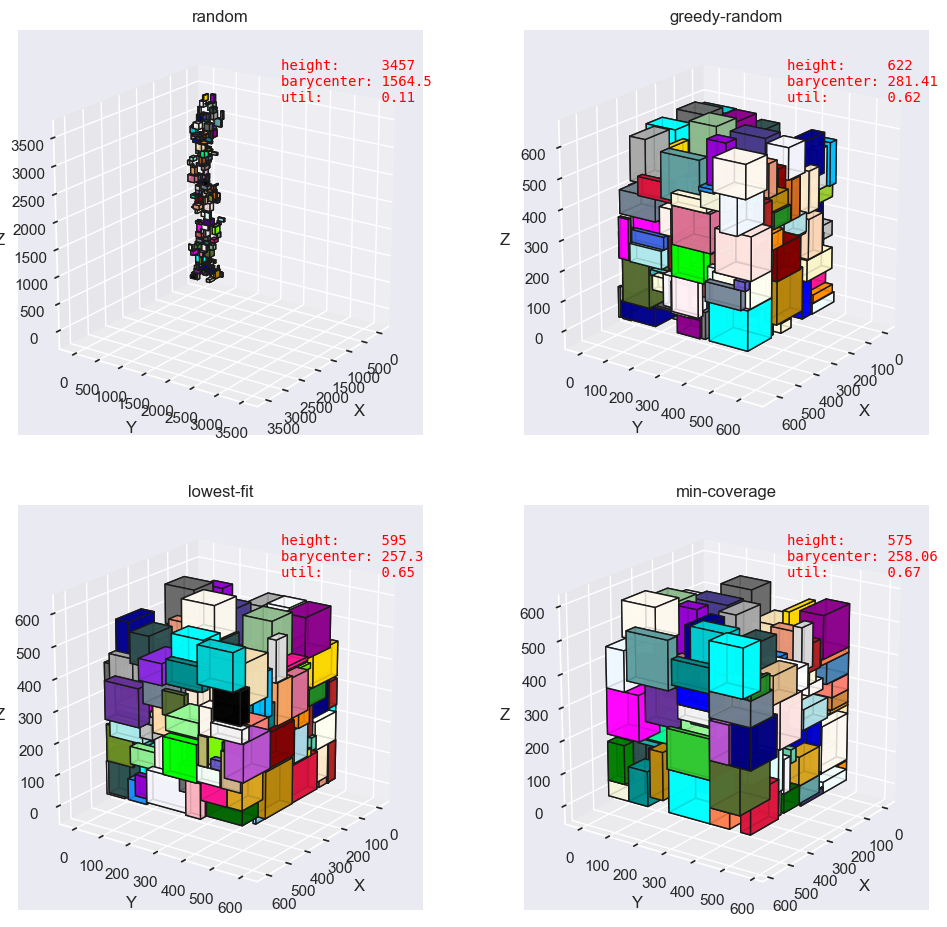

In [63]:
import seaborn as sns
from math import *

# Set seaborn style first
sns.set_theme(style="darkgrid")  # or "darkgrid", "white", "dark"

from matplotlib import colors as mcolors

# Get list of named CSS colors
colors = list(mcolors.CSS4_COLORS.values())

n = len(solutions)
rows = ceil(sqrt(n))
cols = ceil(n / rows)

# Create figure with appropriate size
fig = plt.figure(figsize=(cols*6, rows*5))

for i, solution in enumerate(solutions):
    ax = fig.add_subplot(rows, cols, i + 1, projection='3d')
    items, pos, solution_type_name = solution
    show_solution(items.reshape((-1, 3)), pos.reshape((-1, 3)), solution_type_name, colors=colors, alpha=0.85, ax=ax)
    plt.tight_layout(pad=3.0)


In [12]:
# for 2D:
n = 350
w = 1200
l = 1
k = 0

xmin = 4
xmax = 100
items = np.random.randint(xmin, xmax, 3 * n, dtype=np.int32)
for i in range(n):
    items[3 * i + 1] = 1
# items = np.array([1, 2, 3, 4, 5, 6], dtype=np.int32)

solutions_2d = []

solution_type_list = [
    "random",
    "greedy-random",
    "lowest-fit",
    "min-coverage"
]

lib_solution = prepare_cpp_solutions()

for solution_type_name in solution_type_list:
    moves, pos = get_solution(lib_solution, n, items, w, l, k, solution_type_name)
    solutions_2d.append((items, pos, solution_type_name))


Compilation successful!

{'/Users/belkovanya/coding/github/scientific-work/strip-packing/libmodule.so': <CDLL '/Users/belkovanya/coding/github/scientific-work/strip-packing/libmodule.so', handle 8aaa27d0 at 0x11082edc0>}


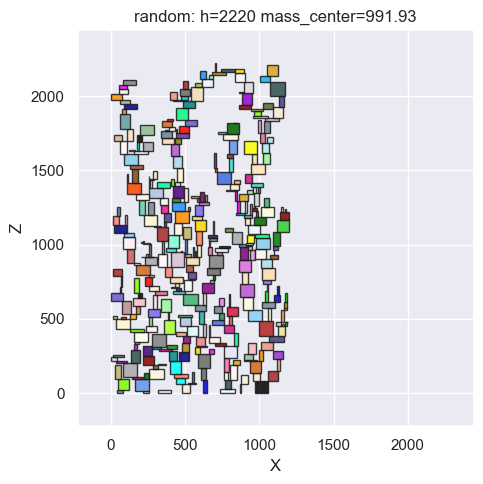

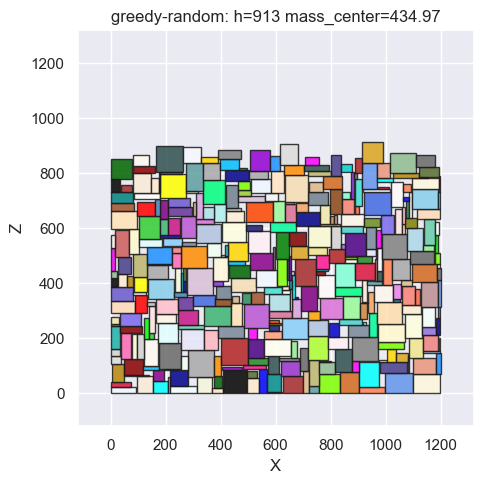

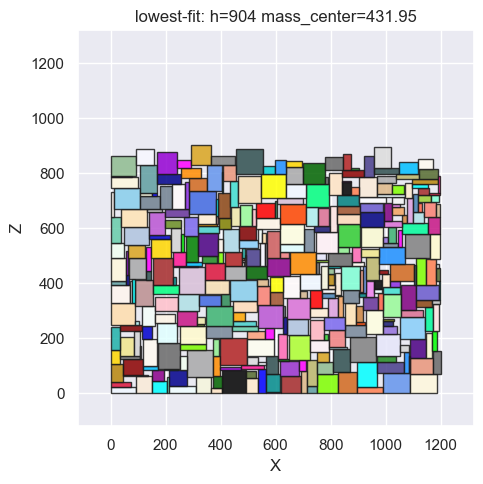

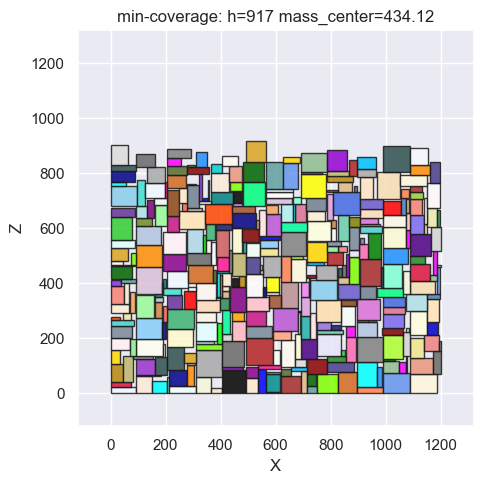

In [13]:
import seaborn as sns

# Set seaborn style first
sns.set_theme(style="darkgrid")  # or "darkgrid", "white", "dark"

from matplotlib import colors as mcolors

# Get list of named CSS colors
colors = list(mcolors.CSS4_COLORS.values())

for solution in solutions_2d:
    items, pos, solution_type_name = solution
    fig, ax = plt.subplots(figsize=(5, 5))
    show_solution_2d(items.reshape((-1, 3)), pos.reshape((-1, 3)), solution_type_name, colors=colors, alpha=0.85, ax=ax)
